Dataset: Ford Car Price Dataset

Target Variable: price (Continuous)

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("ford.csv")

# First 10 rows
df.head(10)

Saving ford.csv to ford.csv


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0


In [ ]:
missing = df.isnull().sum()

missing_percentage = (missing/len(df))*100

print(pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
}))

              Missing Values  Percentage
model                      0         0.0
year                       0         0.0
price                      0         0.0
transmission               0         0.0
mileage                    0         0.0
fuelType                   0         0.0
tax                        0         0.0
mpg                        0         0.0
engineSize                 0         0.0


In [ ]:
df = df.dropna()

In [ ]:
print("Duplicate Rows:",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates After Removal:",df.duplicated().sum())

Duplicate Rows: 154
Duplicates After Removal: 0


In [ ]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000
mean,2016.862396,12269.556310,23381.146362,113.315012,57.908696,1.350623
std,2.052039,4736.285417,19419.011045,62.034603,10.132696,0.432581
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,10000.000000,30.000000,52.300000,1.000000
50%,2017.000000,11288.000000,18277.000000,145.000000,58.900000,1.200000
75%,2018.000000,15295.000000,31098.500000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [ ]:
print("Minimum Price :",df["price"].min())
print("Maximum Price :",df["price"].max())
print("Mean Price :",df["price"].mean())
print("Median Price :",df["price"].median())

Minimum Price : 495
Maximum Price : 54995
Mean Price : 12269.556310352571
Median Price : 11288.0


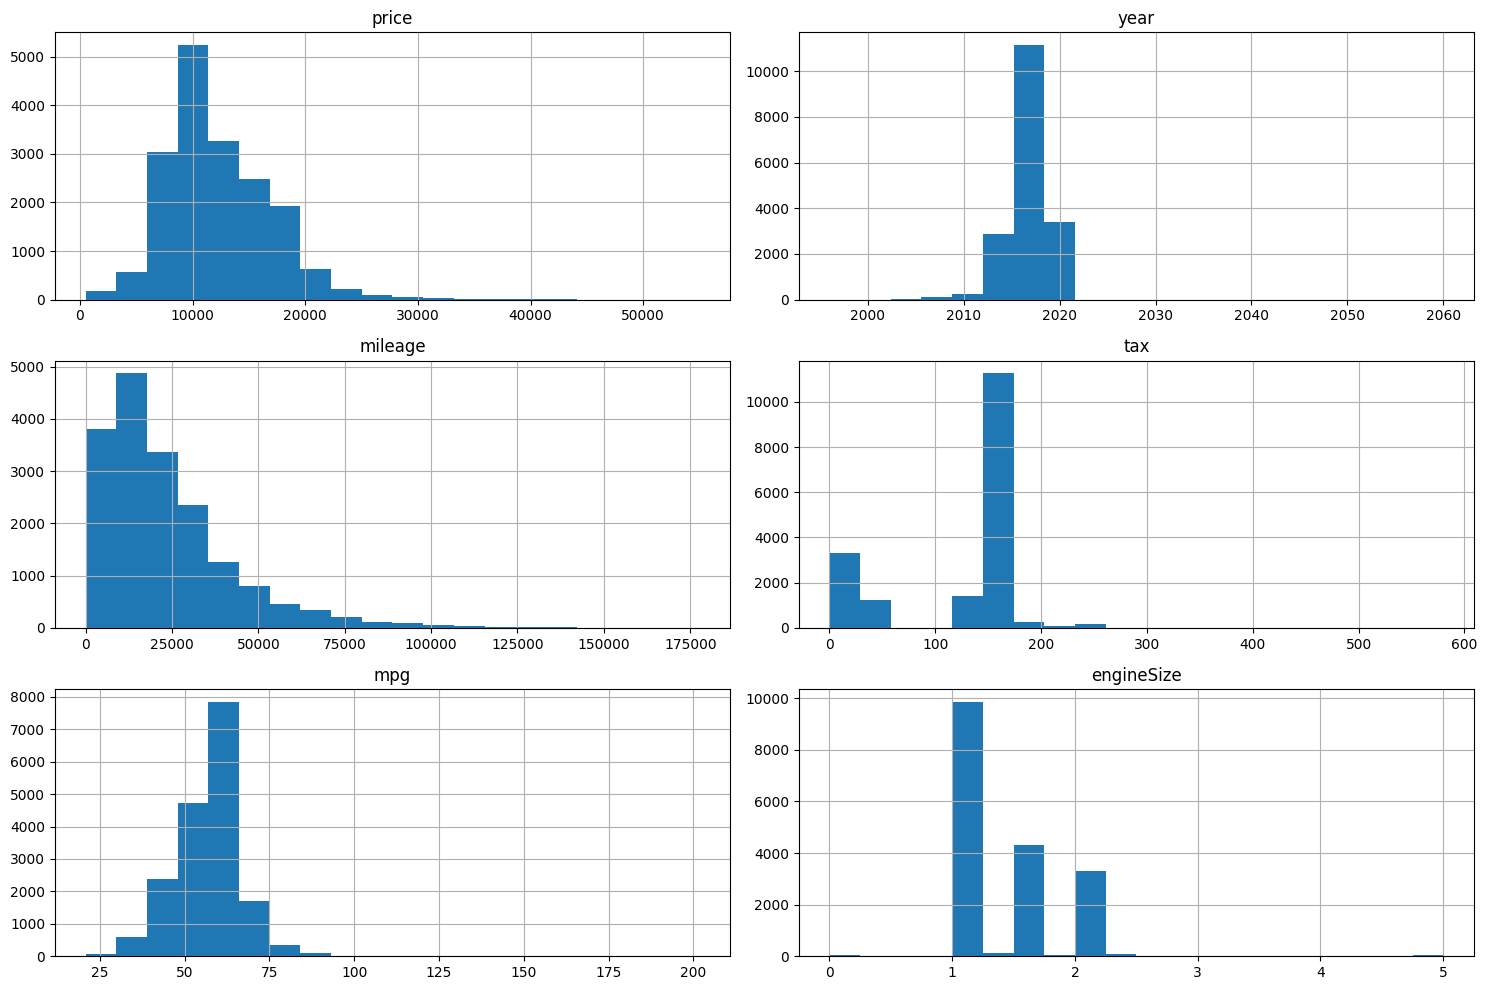

In [ ]:
import matplotlib.pyplot as plt

numeric = ["price","year","mileage","tax","mpg","engineSize"]

df[numeric].hist(figsize=(15,10),bins=20)

plt.tight_layout()

plt.show()

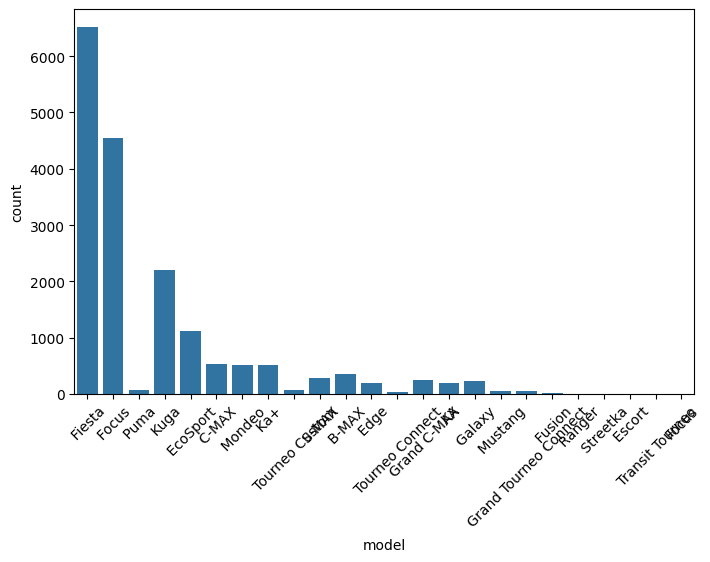

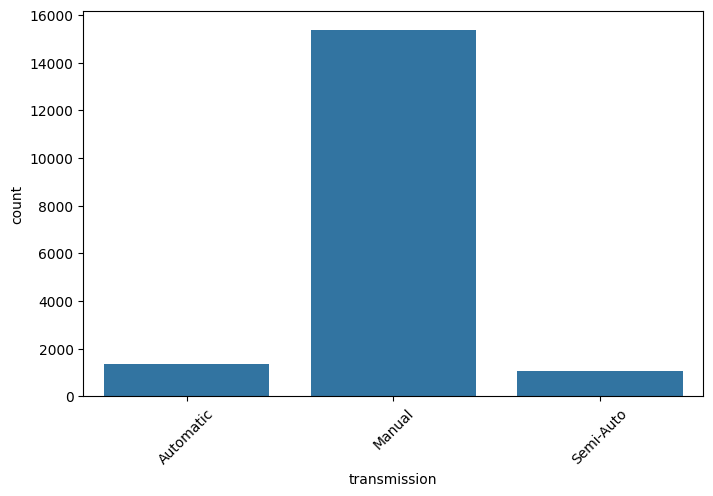

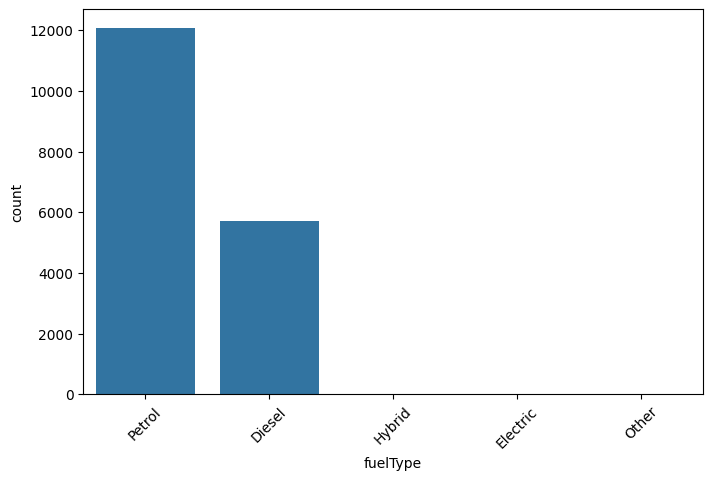

In [ ]:
import seaborn as sns

cat = df.select_dtypes(include="object").columns

for col in cat:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df,x=col)
    plt.xticks(rotation=45)
    plt.show()

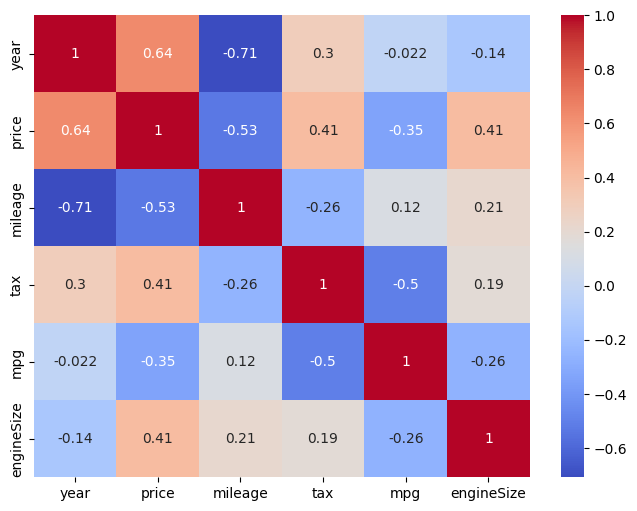

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [ ]:
# Independent Features
X = df.drop("price", axis=1)

# Dependent Feature
y = df["price"]

print("Independent Features (X):")
print(X.columns)

print("\nDependent Feature (y):")
print(y.name)

Independent Features (X):
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

Dependent Feature (y):
price


In [ ]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include='object').columns
print("Categorical Columns:")
print(categorical_columns)
# Before Encoding (First 5 rows)
print("\nBefore Encoding:")
print(df[['model', 'transmission']].head())
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
# After Encoding (First 5 rows)
print("\nAfter Encoding:")
print(df_encoded.filter(regex='model|transmission').head())


Categorical Columns:
Index(['model', 'transmission', 'fuelType'], dtype='object')

Before Encoding:
     model transmission
0   Fiesta    Automatic
1    Focus       Manual
2    Focus       Manual
3   Fiesta       Manual
4   Fiesta    Automatic

After Encoding:
   model_ C-MAX  model_ EcoSport  model_ Edge  model_ Escort  model_ Fiesta  \
0         False            False        False          False           True   
1         False            False        False          False          False   
2         False            False        False          False          False   
3         False            False        False          False           True   
4         False            False        False          False           True   

   model_ Focus  model_ Fusion  model_ Galaxy  model_ Grand C-MAX  \
0         False          False          False               False   
1          True          False          False               False   
2          True          False          False            

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

       year   mileage       tax       mpg  engineSize  model_ C-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561     -0.177155   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561     -0.177155   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561     -0.177155   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325     -0.177155   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561     -0.177155   

   model_ EcoSport  model_ Edge  model_ Escort  model_ Fiesta  ...  \
0        -0.259896    -0.107903      -0.007493       1.317770  ...   
1        -0.259896    -0.107903      -0.007493      -0.758858  ...   
2        -0.259896    -0.107903      -0.007493      -0.758858  ...   
3        -0.259896    -0.107903      -0.007493       1.317770  ...   
4        -0.259896    -0.107903      -0.007493       1.317770  ...   

   model_ Tourneo Connect  model_ Tourneo Custom  model_ Transit Tourneo  \
0               -0.042424              -0.062361               -0.007493   


Summary

The Ford Car Dataset was successfully explored and preprocessed. Missing values and duplicate records were handled, statistical analysis was performed, histograms and count plots were used to understand feature distributions, and a correlation heatmap identified relationships among numerical variables. Categorical variables were encoded using One-Hot Encoding, and all independent features were standardized using StandardScaler. The dataset is now clean and ready for building a regression model to predict car prices.